In [118]:
import scipy as sp
from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones
import torch
from numpy import pi, exp, conj, min, argmin, unravel_index, log
import warnings
warnings.filterwarnings("ignore")

In [72]:
M = 1000
epsilon = 1
x = linspace(100, 110, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [73]:
l = 5
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

In [74]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [75]:
asymptotic_denom = (-1)**l+1j*exp(2*1j*y)
asymptotic_num = (-1)**l*(1-m)+1j*(m+1)*exp(2*1j*y)
sigmas_asymptotic = asymptotic_num/asymptotic_denom 

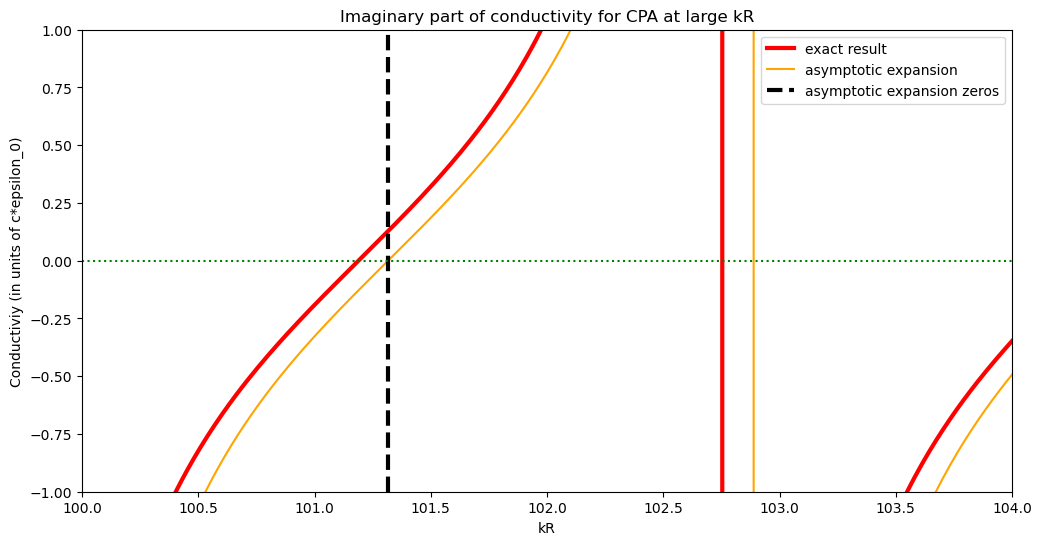

In [80]:
x_1 = 100
x_2 = 104
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax.set_ylim(-1, 1)
ax.vlines([pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.set_xlim(x_1, x_2);
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

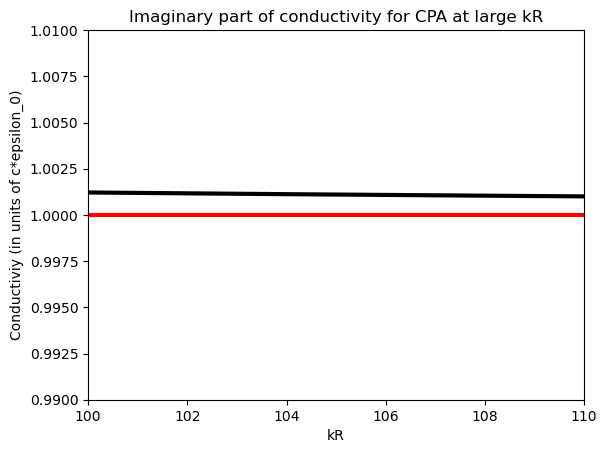

In [277]:
plt.plot(x, sigmas[0, :], color="black", linewidth=3)
plt.plot(x, sigmas_asymptotic.real, color="red", linewidth=3)

#plt.vlines([-pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3)
plt.xlim(100, 110);
plt.ylim(0.99, 1.01)
plt.xlabel("kR")
plt.ylabel("Conductiviy (in units of c*epsilon_0)");
plt.title("Imaginary part of conductivity for CPA at large kR");

In [150]:
M = 1000
epsilon = 1
x = linspace(0.001, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [151]:
l = 1
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

In [152]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [153]:
sigmas[:, np.argmin(np.abs(x-0.1))]

array([0.00160107, 0.20267125])

In [154]:
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]

In [155]:
quasistatic_dispersion = (1+epsilon)*x/l

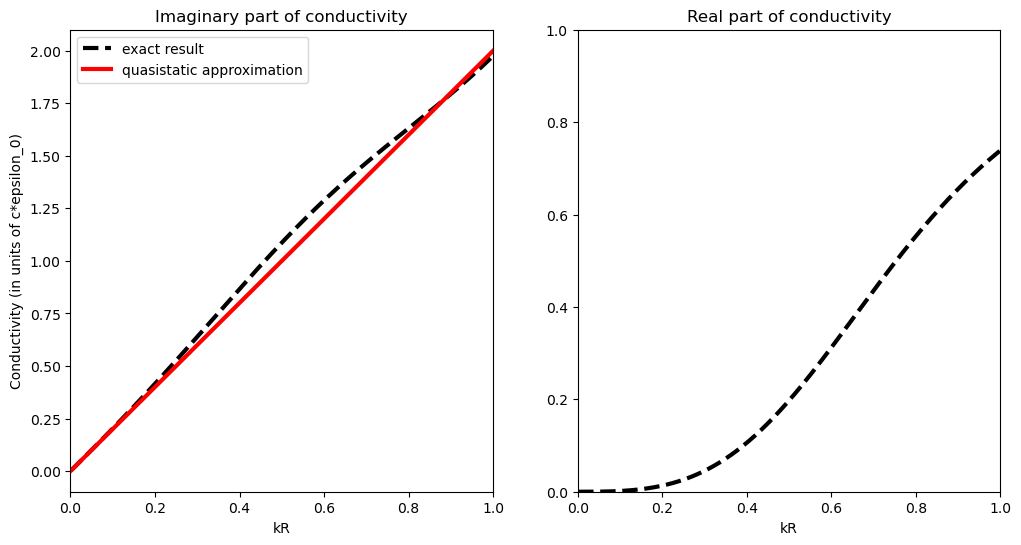

In [156]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, quasistatic_dispersion, label="quasistatic approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.set_xlim(0, 1)
#ax1.set_ylim(0, 2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.set_ylim(0, 1)
ax2.set_xlim(0, 1)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");


In [157]:
hbar = 6.67*1e-16 # hbar in eV*seconds
tau = 6.4*1e-13 # scattering time in seconds
c = 3*10**17; # speed of light in nanometers per second
alpha = 1/137; # fine structure constant

In [158]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;

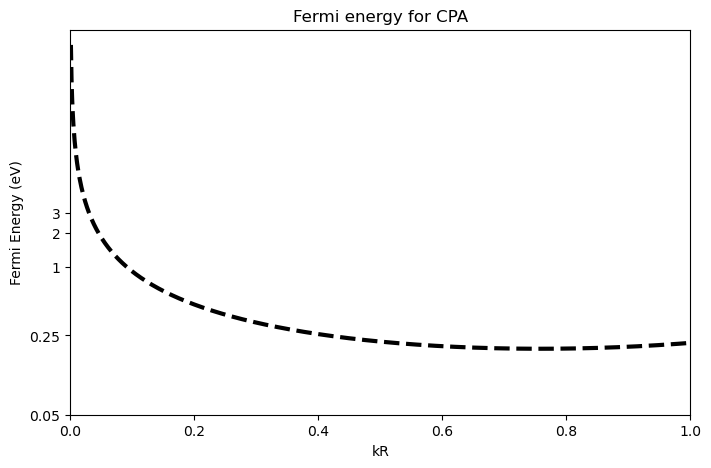

In [159]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, log(E_F), color="black", linestyle="dashed", linewidth=3)
ax.set_yticks([log(0.05), log(0.25), log(1), log(2), log(3)], [0.05, 0.25, 1, 2, 3])
#ax.set_ylim(log(0.05), log(3));
ax.set_xlim(0, 1)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.set_title("Fermi energy for CPA");

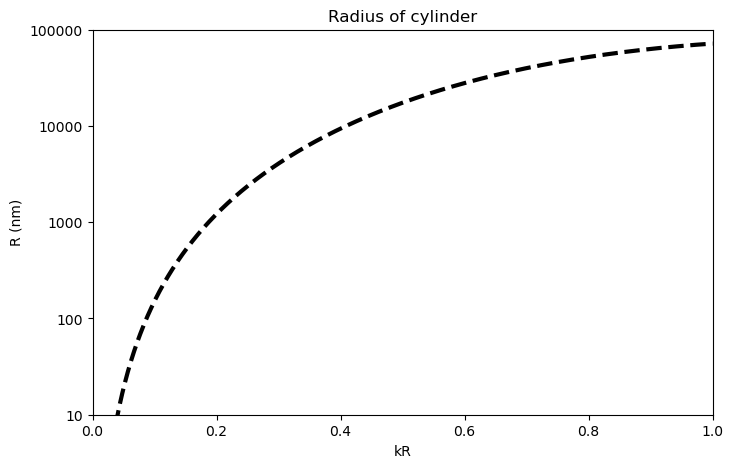

In [160]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, log(a), color="black", linestyle="dashed", linewidth=3)
ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(0, 1)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of cylinder");

### Radiative ($E=E_z$) modes

In [36]:
M = 1000
epsilon = 1
x = linspace(100, 110, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [50]:
l = 5
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])

In [51]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [52]:
asymptotic_denom = (-1)**(l+1)+1j*exp(2*1j*y)
asymptotic_num = (-1)**(l+1)*(1-m)+1j*(m+1)*exp(2*1j*y)
sigmas_asymptotic = asymptotic_num/asymptotic_denom 

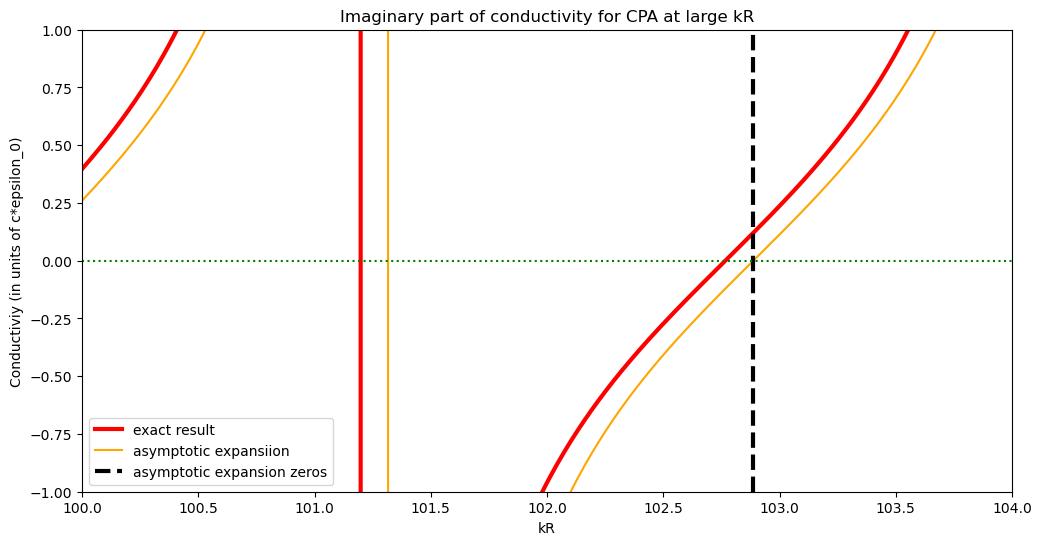

In [64]:
x_1 = 100
x_2 = 104
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansiion")
ax.set_ylim(-1, 1)
ax.vlines([-pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlim(x_1, x_2);
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

In [262]:
M = 1000
epsilon = 1
x_1 = 1e-3
x_2 = 5e-3
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [263]:
l = 1
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])

In [264]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)
sigma_real = sigmas[0, :]
sigma_imaginary = sigmas[1, :]

In [265]:
sigma = sigmas[:, np.argmin(np.abs(x-0.1))]

In [266]:
small_cylinder_dispersion = -(2*l)/x

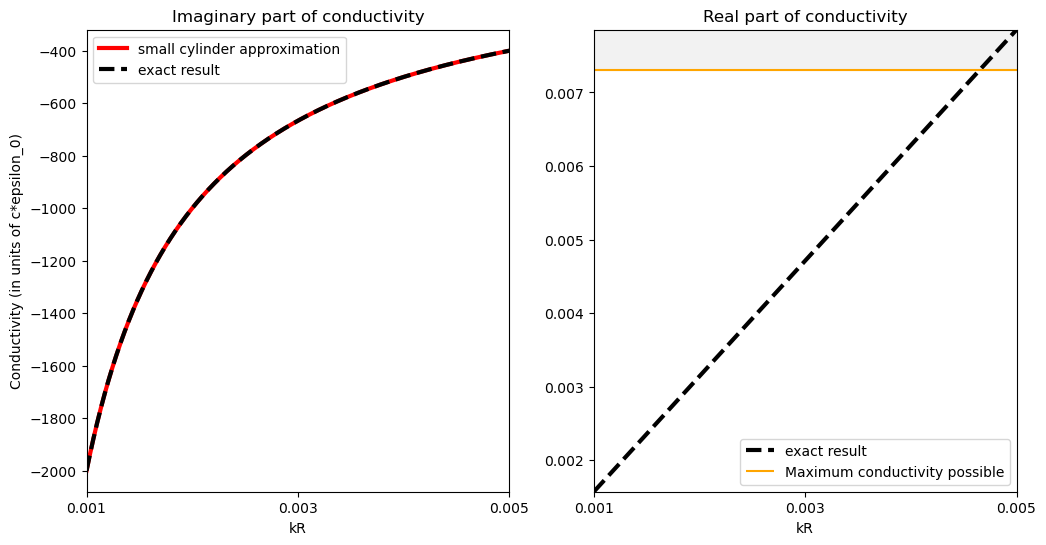

In [276]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.plot(x, small_cylinder_dispersion, label="small cylinder approximation", color="red", linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
ax1.plot(x, sigma_imaginary, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax1.set_xlim(x_1, x_2)
ax1.set_title("Imaginary part of conductivity")
ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
ax1.set_xlabel("kR");
ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.legend();

ax2.plot(x, sigma_real, label="exact result", color="black", linestyle="dashed", linewidth=3)
ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
ax2.set_xlim(x_1, x_2)
ax2.set_xlabel("kR");
ax2.set_title("Real part of conductivity");
ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
ax2.set_xticks([x_1, (x_1+x_2)/2, x_2]);
ax2.set_ylim(sigma_real.min(), sigma_real.max())
ax2.legend();

In [285]:
E_F_1 = (hbar/tau)*(alpha+sqrt(alpha**2-sigma_real**2))/(2*sigma_real);
E_F_2 = (hbar/tau)*(alpha-sqrt(alpha**2-sigma_real**2))/(2*sigma_real);

a_1 = c*x*hbar/E_F_1;
a_2 = c*x*hbar/E_F_2;

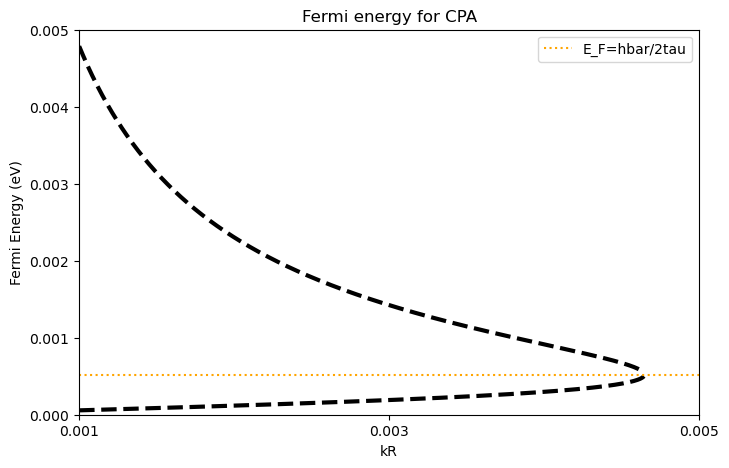

In [290]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, E_F_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, E_F_2, color="black", linestyle="dashed", linewidth=3)

ax.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax.set_xlim(x_1, x_2)
ax.set_ylim(0, 0.005)
ax.set_xlabel("kR");
ax.set_ylabel("Fermi Energy (eV)");
ax.hlines([hbar/(2*tau)], x_1, x_2, linestyle="dotted", color="orange", label="E_F=hbar/2tau")
ax.legend()
ax.set_title("Fermi energy for CPA");

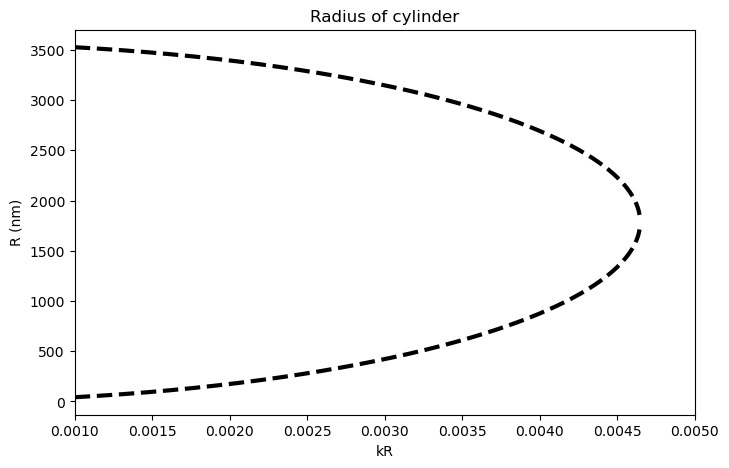

In [287]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, a_1, color="black", linestyle="dashed", linewidth=3)
ax.plot(x, a_2, color="black", linestyle="dashed", linewidth=3)

#ax.set_yticks([log(1e1), log(1e2), log(1e3), log(1e4), log(1e5)], [10, 100, 1000, 10000, 100000])
#ax.set_ylim(log(1e1), log(1e5));
ax.set_xlim(x_1, x_2)
#ax.set_ylim(10, 1000)
ax.set_xlabel("kR");
ax.set_ylabel("R (nm)");
ax.set_title("Radius of cylinder");